In [ ]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Color palette for the two methods
METHOD_COLORS = {
    'Full Tank': '#2980b9', # Blue
    'DCA': '#d35400'        # Orange
}

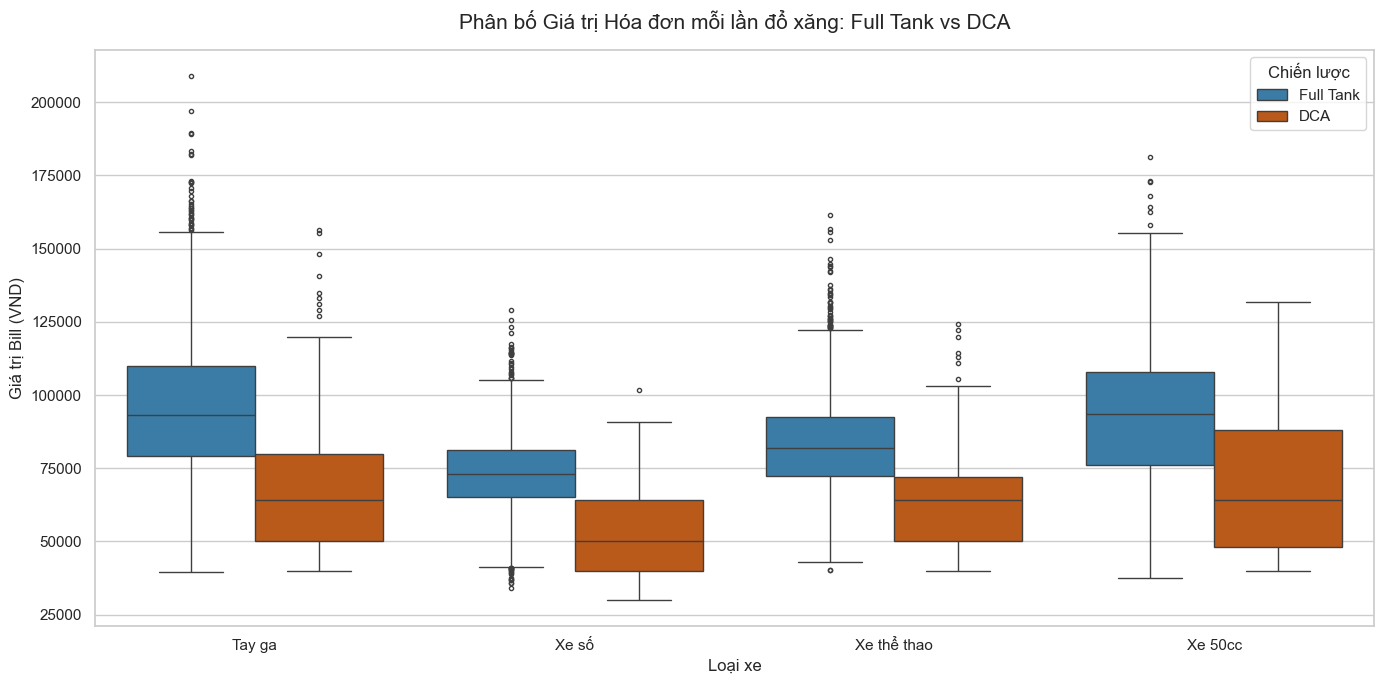

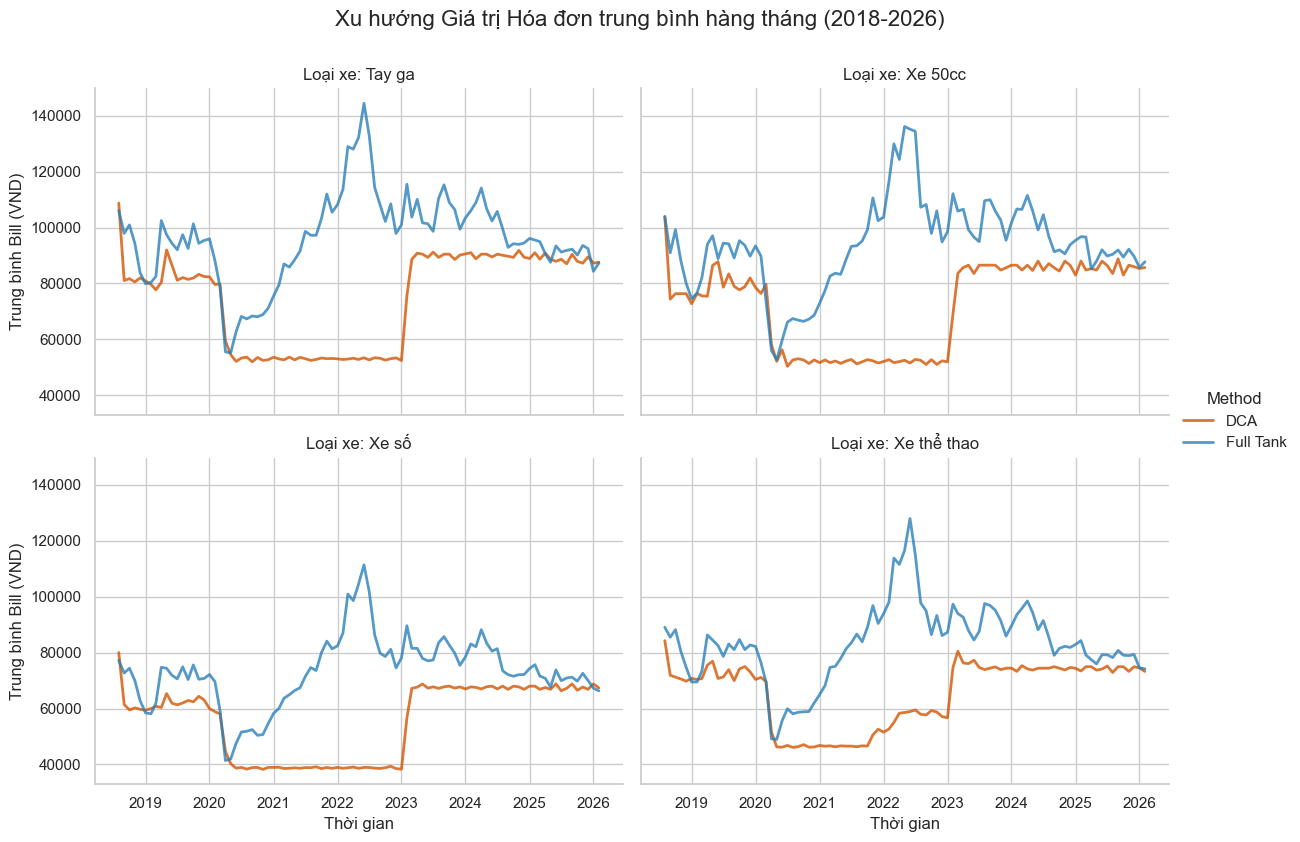

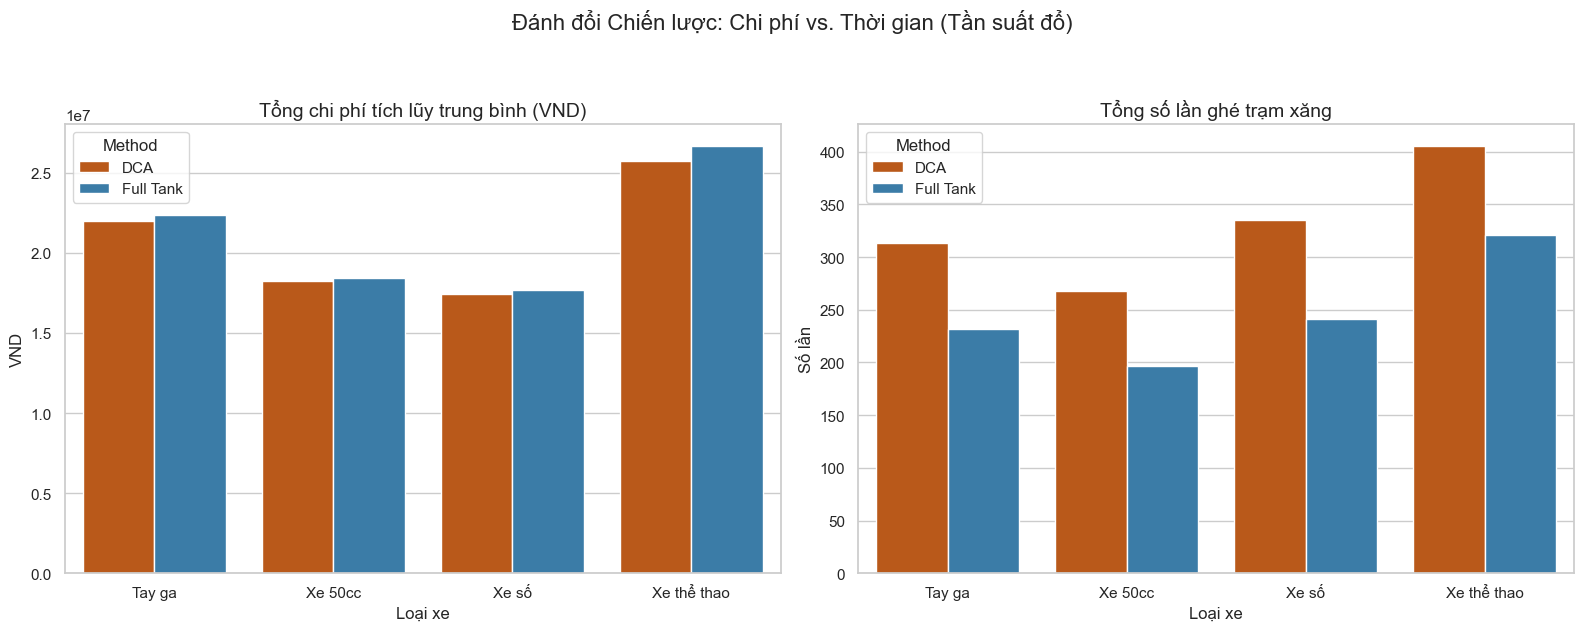

In [2]:

def visualize_side_by_side(
    full_tank_path="/Users/my/DCA-on-filling-your-motorbike/01.fuel_purchase_history.json",
    dca_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json",
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not all(os.path.exists(p) for p in [full_tank_path, dca_path, csv_path]):
        print("Lỗi: Không tìm thấy một hoặc nhiều file cấu hình.")
        return

    # 1. Process Bike Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip()
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    history_records = []
    summary_records = []

    # 2. Parse FULL TANK Data
    with open(full_tank_path, 'r', encoding='utf-8') as f:
        ft_data = json.load(f)
        for bike_name, info in ft_data.items():
            v_type = type_map.get(bike_name.strip(), "Khác")
            summary_records.append({
                "bike_name": bike_name.strip(), "type": v_type, "Method": "Full Tank",
                "total_spent": info.get('total_spent', 0),
                "total_purchases": info.get('total_purchases', 0)
            })
            for record in info.get('history', []):
                history_records.append({
                    "date": record['date'], "cost_vnd": record['cost_vnd'],
                    "type": v_type, "Method": "Full Tank"
                })

    # 3. Parse DCA Data (Handling the nested 'summary' key)
    with open(dca_path, 'r', encoding='utf-8') as f:
        dca_data = json.load(f)
        for bike_name, info in dca_data.items():
            v_type = type_map.get(bike_name.strip(), "Khác")
            summary = info.get('summary', {})
            summary_records.append({
                "bike_name": bike_name.strip(), "type": v_type, "Method": "DCA",
                "total_spent": summary.get('total_spent_vnd', 0),
                "total_purchases": summary.get('total_purchases', 0)
            })
            for record in info.get('history', []):
                history_records.append({
                    "date": record['date'], "cost_vnd": record['cost_vnd'],
                    "type": v_type, "Method": "DCA"
                })

    # 4. Data Formatting
    history_df = pd.DataFrame(history_records)
    summary_df = pd.DataFrame(summary_records)
    
    history_df['date'] = pd.to_datetime(history_df['date'], format='%d-%m-%Y', errors='coerce')
    sns.set_theme(style="whitegrid")

    # --- CHART 1: BOXPLOT OF BILL SIZES ---
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=history_df, x='type', y='cost_vnd', hue='Method', 
        palette=METHOD_COLORS, fliersize=3
    )
    plt.title("Phân bố Giá trị Hóa đơn mỗi lần đổ xăng: Full Tank vs DCA", fontsize=15, pad=15)
    plt.xlabel("Loại xe", fontsize=12)
    plt.ylabel("Giá trị Bill (VND)", fontsize=12)
    plt.legend(title="Chiến lược")
    plt.tight_layout()
    plt.show()

    # --- CHART 2: LINE CHARTS OF BILL SIZES OVER TIME (By Bike Type) ---
    # Calculate monthly average bill size to smooth out the lines
    monthly_avg = history_df.groupby(['type', 'Method', history_df['date'].dt.to_period('M')])['cost_vnd'].mean().reset_index()
    monthly_avg['date'] = monthly_avg['date'].dt.to_timestamp() # Convert back for plotting

    g = sns.relplot(
        data=monthly_avg, x='date', y='cost_vnd', hue='Method', col='type', 
        col_wrap=2, kind='line', palette=METHOD_COLORS, height=4, aspect=1.5,
        linewidth=2, alpha=0.8
    )
    g.fig.suptitle("Xu hướng Giá trị Hóa đơn trung bình hàng tháng (2018-2026)", y=1.05, fontsize=16)
    g.set_axis_labels("Thời gian", "Trung bình Bill (VND)")
    g.set_titles("Loại xe: {col_name}")
    plt.show()

    # --- CHART 3: THE TRADEOFF (Total Spent vs Total Purchases) ---
    # Group by bike name and method to compare absolute totals side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left Axis: Total Spent
    sns.barplot(
        data=summary_df.groupby(['type', 'Method'])['total_spent'].mean().reset_index(),
        x='type', y='total_spent', hue='Method', palette=METHOD_COLORS, ax=axes[0]
    )
    axes[0].set_title("Tổng chi phí tích lũy trung bình (VND)", fontsize=14)
    axes[0].set_xlabel("Loại xe")
    axes[0].set_ylabel("VND")
    
    # Right Axis: Total Purchases (Trips to gas station)
    sns.barplot(
        data=summary_df.groupby(['type', 'Method'])['total_purchases'].mean().reset_index(),
        x='type', y='total_purchases', hue='Method', palette=METHOD_COLORS, ax=axes[1]
    )
    axes[1].set_title("Tổng số lần ghé trạm xăng", fontsize=14)
    axes[1].set_xlabel("Loại xe")
    axes[1].set_ylabel("Số lần")
    
    plt.suptitle("Đánh đổi Chiến lược: Chi phí vs. Thời gian (Tần suất đổ)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_side_by_side()

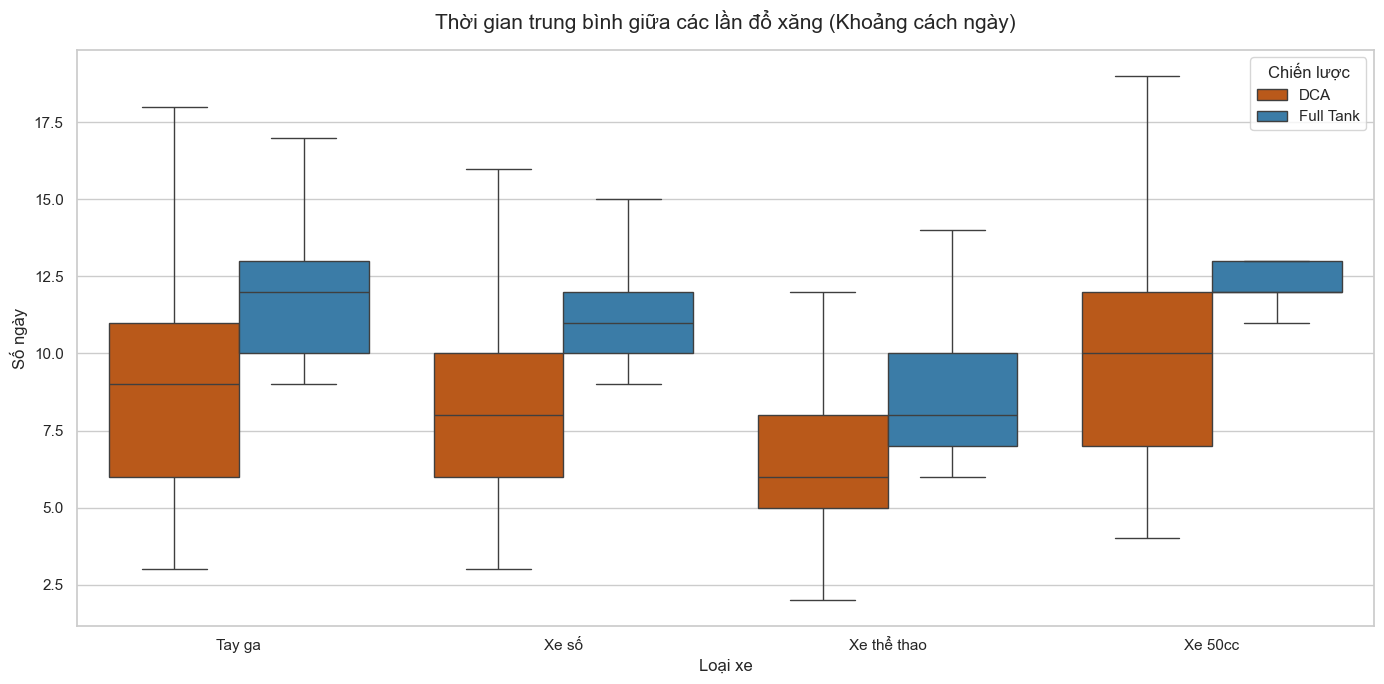

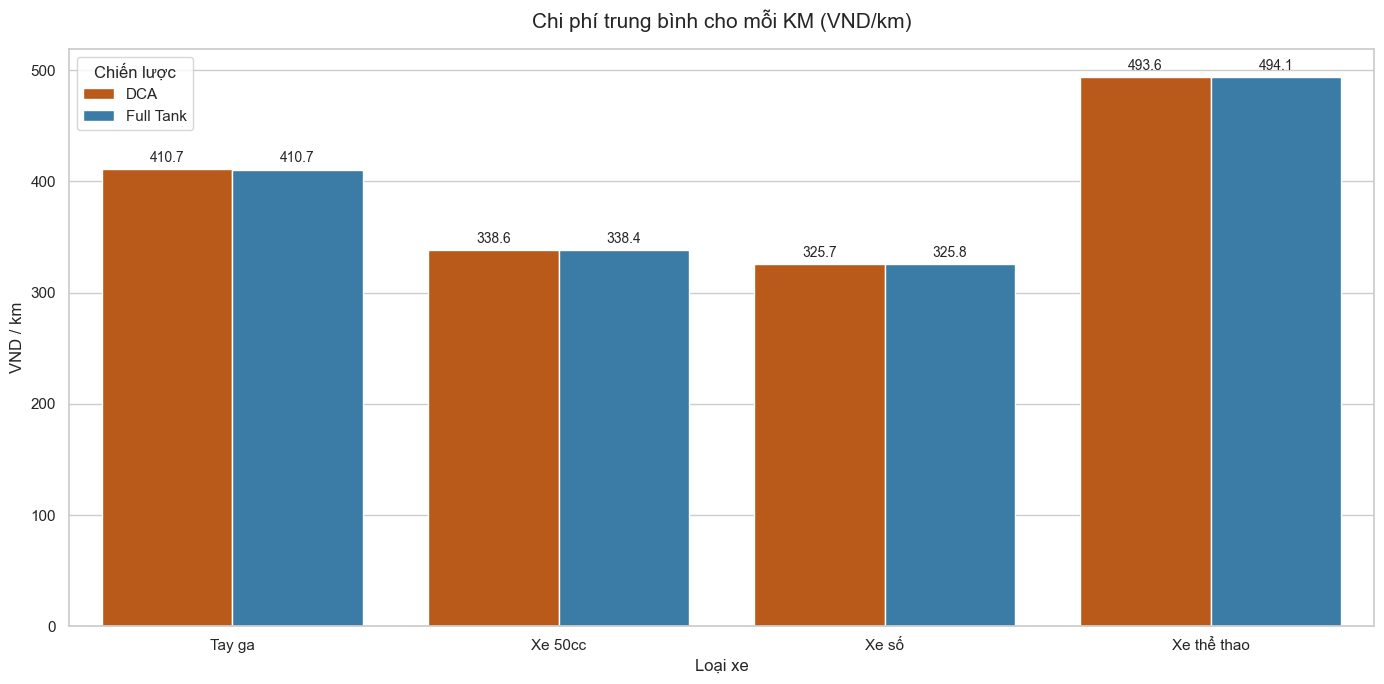

In [7]:

def visualize_comprehensive_comparison(
    full_tank_path="/Users/my/DCA-on-filling-your-motorbike/01.fuel_purchase_history.json",
    dca_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json",
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not all(os.path.exists(p) for p in [full_tank_path, dca_path, csv_path]):
        print("Lỗi: Không tìm thấy một hoặc nhiều file cấu hình.")
        return

    # 1. Process Bike Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip()
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    history_records = []
    summary_records = []
    
    # Dictionary to store consumption rates from Full Tank data to use across both methods
    consumption_map = {}

    # 2. Parse FULL TANK Data
    with open(full_tank_path, 'r', encoding='utf-8') as f:
        ft_data = json.load(f)
        for bike_name, info in ft_data.items():
            bike_name = bike_name.strip()
            v_type = type_map.get(bike_name, "Khác")
            
            # Extract consumption rate (L/100km)
            cons_rate = info.get('specs', {}).get('consumption_rate', 2.0)
            consumption_map[bike_name] = cons_rate
            
            total_spent = info.get('total_spent', 0)
            total_purchases = info.get('total_purchases', 0)
            
            # Calculate total liters to find total km
            history = info.get('history', [])
            total_liters = sum(r.get('volume_liters', 0) for r in history)
            total_km = total_liters * (100 / cons_rate) if cons_rate > 0 else 1
            cost_per_km = total_spent / total_km if total_km > 0 else 0

            summary_records.append({
                "bike_name": bike_name, "type": v_type, "Method": "Full Tank",
                "total_spent": total_spent, "total_purchases": total_purchases,
                "cost_per_km": cost_per_km
            })
            for record in history:
                history_records.append({
                    "bike_name": bike_name, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "volume_liters": record.get('volume_liters', 0),
                    "type": v_type, "Method": "Full Tank"
                })

    # 3. Parse DCA Data
    with open(dca_path, 'r', encoding='utf-8') as f:
        dca_data = json.load(f)
        for bike_name, info in dca_data.items():
            bike_name = bike_name.strip()
            v_type = type_map.get(bike_name, "Khác")
            
            summary = info.get('summary', {})
            total_spent = summary.get('total_spent_vnd', 0)
            total_purchases = summary.get('total_purchases', 0)
            
            # Get consumption rate from our map (or default)
            cons_rate = consumption_map.get(bike_name, 2.0)
            
            history = info.get('history', [])
            total_liters = sum(r.get('volume_liters', 0) for r in history)
            total_km = total_liters * (100 / cons_rate) if cons_rate > 0 else 1
            cost_per_km = total_spent / total_km if total_km > 0 else 0

            summary_records.append({
                "bike_name": bike_name, "type": v_type, "Method": "DCA",
                "total_spent": total_spent, "total_purchases": total_purchases,
                "cost_per_km": cost_per_km
            })
            for record in history:
                history_records.append({
                    "bike_name": bike_name, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "volume_liters": record.get('volume_liters', 0),
                    "type": v_type, "Method": "DCA"
                })

    # 4. Data Formatting & Time-Delta Calculation
    history_df = pd.DataFrame(history_records)
    summary_df = pd.DataFrame(summary_records)
    
    # Calculate days between refuels
    history_df['date'] = pd.to_datetime(history_df['date'], format='%d-%m-%Y', errors='coerce')
    history_df = history_df.sort_values(by=['Method', 'bike_name', 'date'])
    history_df['days_between'] = history_df.groupby(['Method', 'bike_name'])['date'].diff().dt.days

    sns.set_theme(style="whitegrid")

    # --- NEW CHART 3: TIME BETWEEN REFUELS (DAYS) ---
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=history_df.dropna(subset=['days_between']), 
        x='type', 
        y='days_between', 
        hue='Method', 
        palette=METHOD_COLORS,
        showfliers=False # Hiding outliers to make the core distribution clearer
    )
    plt.title("Thời gian trung bình giữa các lần đổ xăng (Khoảng cách ngày)", fontsize=15, pad=15)
    plt.xlabel("Loại xe", fontsize=12)
    plt.ylabel("Số ngày", fontsize=12)
    plt.legend(title="Chiến lược")
    plt.tight_layout()
    plt.show()

    # --- NEW CHART 4: AVERAGE COST PER KM ---
    plt.figure(figsize=(14, 7))
    avg_km_cost = summary_df.groupby(['type', 'Method'])['cost_per_km'].mean().reset_index()
    
    ax = sns.barplot(
        data=avg_km_cost, 
        x='type', 
        y='cost_per_km', 
        hue='Method', 
        palette=METHOD_COLORS
    )
    plt.title("Chi phí trung bình cho mỗi KM (VND/km)", fontsize=15, pad=15)
    plt.xlabel("Loại xe", fontsize=12)
    plt.ylabel("VND / km", fontsize=12)
    
    # Add exact numbers on top of the bars for precision
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
        
    plt.legend(title="Chiến lược")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_comprehensive_comparison()

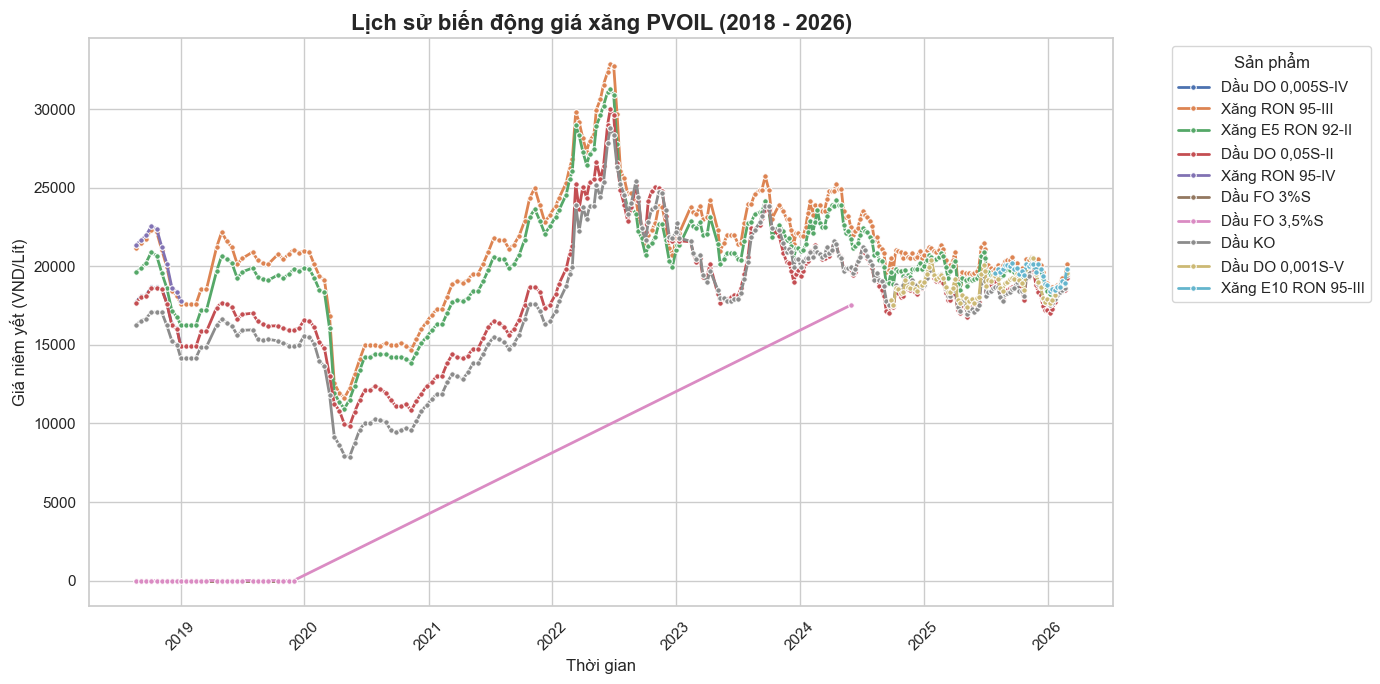

In [4]:

def report_fuel_price_trends(json_path="pvoil_prices.json"):
    # 1. Đọc dữ liệu JSON
    if not os.path.exists(json_path):
        print(f"Không tìm thấy file {json_path}")
        return
        
    with open(json_path, 'r', encoding='utf-8') as f:
        price_data = json.load(f)

    # 2. Chuyển đổi JSON sang DataFrame
    price_records = []
    for date_str, info in price_data.items():
        # Lấy danh sách xăng trong ngày đó
        fuels = info.get('fuels', [])
        for item in fuels:
            price_records.append({
                "Ngày": date_str,
                "Loại xăng": item['fuel_type'],
                "Giá (VND)": item['price_vnd']
            })

    df = pd.DataFrame(price_records)
    
    # Chuyển cột Ngày sang định dạng datetime và sắp xếp
    df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d-%m-%Y')
    df = df.sort_values('Ngày')

    # 3. Vẽ biểu đồ
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))

    # Vẽ đường line cho từng loại xăng
    sns.lineplot(data=df, x='Ngày', y='Giá (VND)', hue='Loại xăng', linewidth=2, marker='o', markersize=4)

    # Định dạng biểu đồ
    plt.title("Lịch sử biến động giá xăng PVOIL (2018 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Thời gian", fontsize=12)
    plt.ylabel("Giá niêm yết (VND/Lít)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Sản phẩm", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    report_fuel_price_trends()



Here is the breakdown of the phases based on the visual evidence:

### **The 5 Market Phases (2018 - 2026)**

1. **Phase 1: Pre-COVID Stability (Aug 2018 – Feb 2020)**
* **Characteristics:** Moderate fluctuation. Prices hovered comfortably around the 20,000 VND/L mark for RON 95. Normal market dynamics applied.


2. **Phase 2: The COVID Crash (Mar 2020 – Nov 2020)**
* **Characteristics:** Historic collapse in demand. Prices plummeted vertically, bottoming out around 11,000 VND/L. High volatility on the way down, followed by a brief period of extreme cheapness.


3. **Phase 3: The Great Inflation & Supply Shock (Dec 2020 – Jul 2022)**
* **Characteristics:** A relentless, aggressive bull market. Driven by post-COVID recovery and later exacerbated by the Russia-Ukraine conflict. Prices hit all-time highs, peaking well above 30,000 VND/L.


4. **Phase 4: The Correction (Aug 2022 – Dec 2022)**
* **Characteristics:** Rapid deflation of the bubble. Prices fell off a cliff back down to the low 20,000s as global supply chains adjusted and government interventions (like tax cuts) took effect.


5. **Phase 5: The "New Normal" Sideways Market (Jan 2023 – Mar 2026)**
* **Characteristics:** Range-bound volatility. Prices have been fluctuating in a tighter band mostly between 20,000 and 25,000 VND/L, with a slight downward trend as we move into 2025/2026.


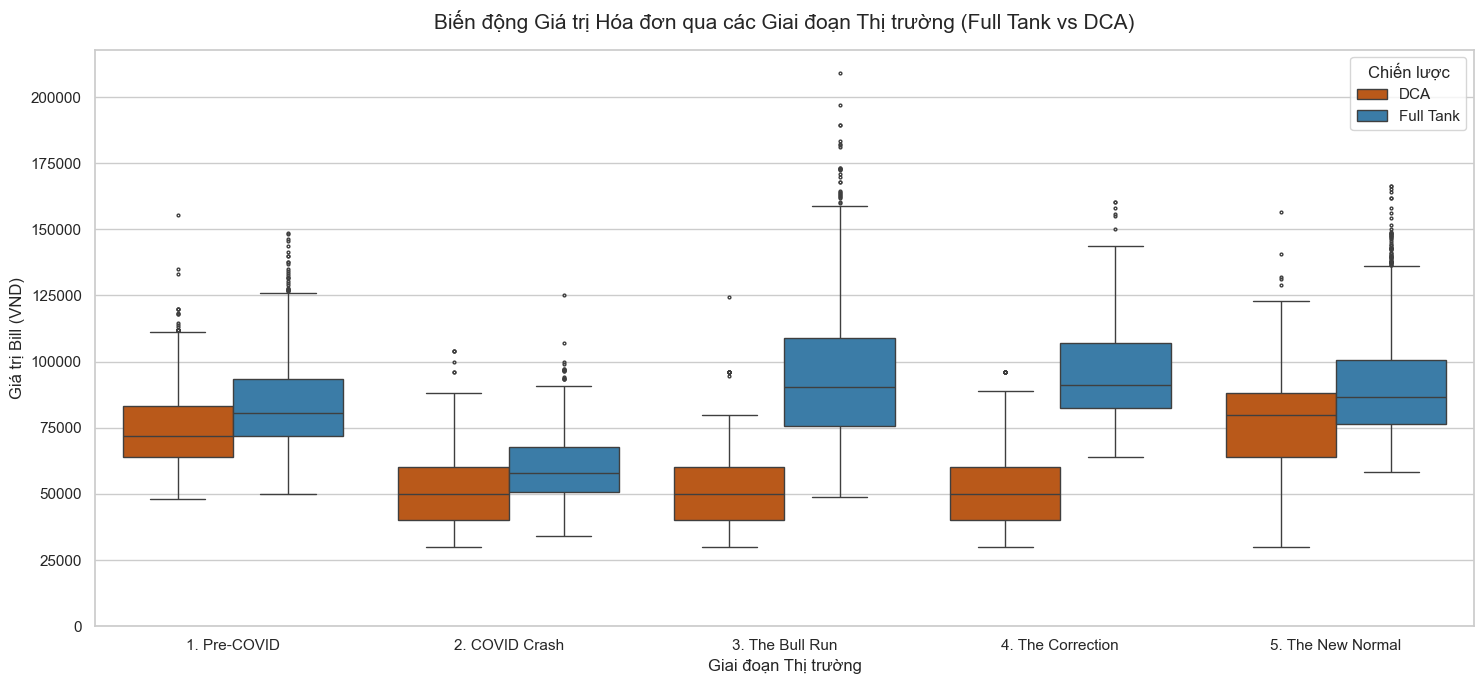

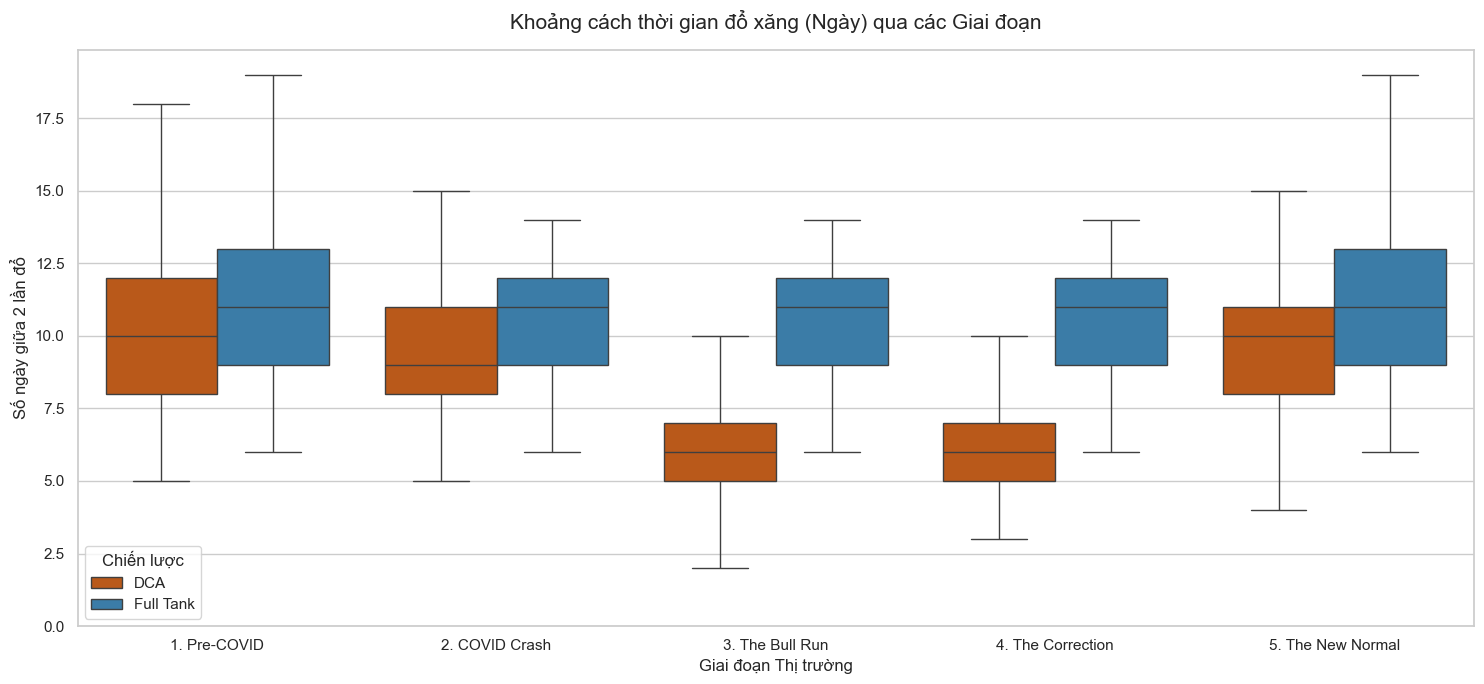

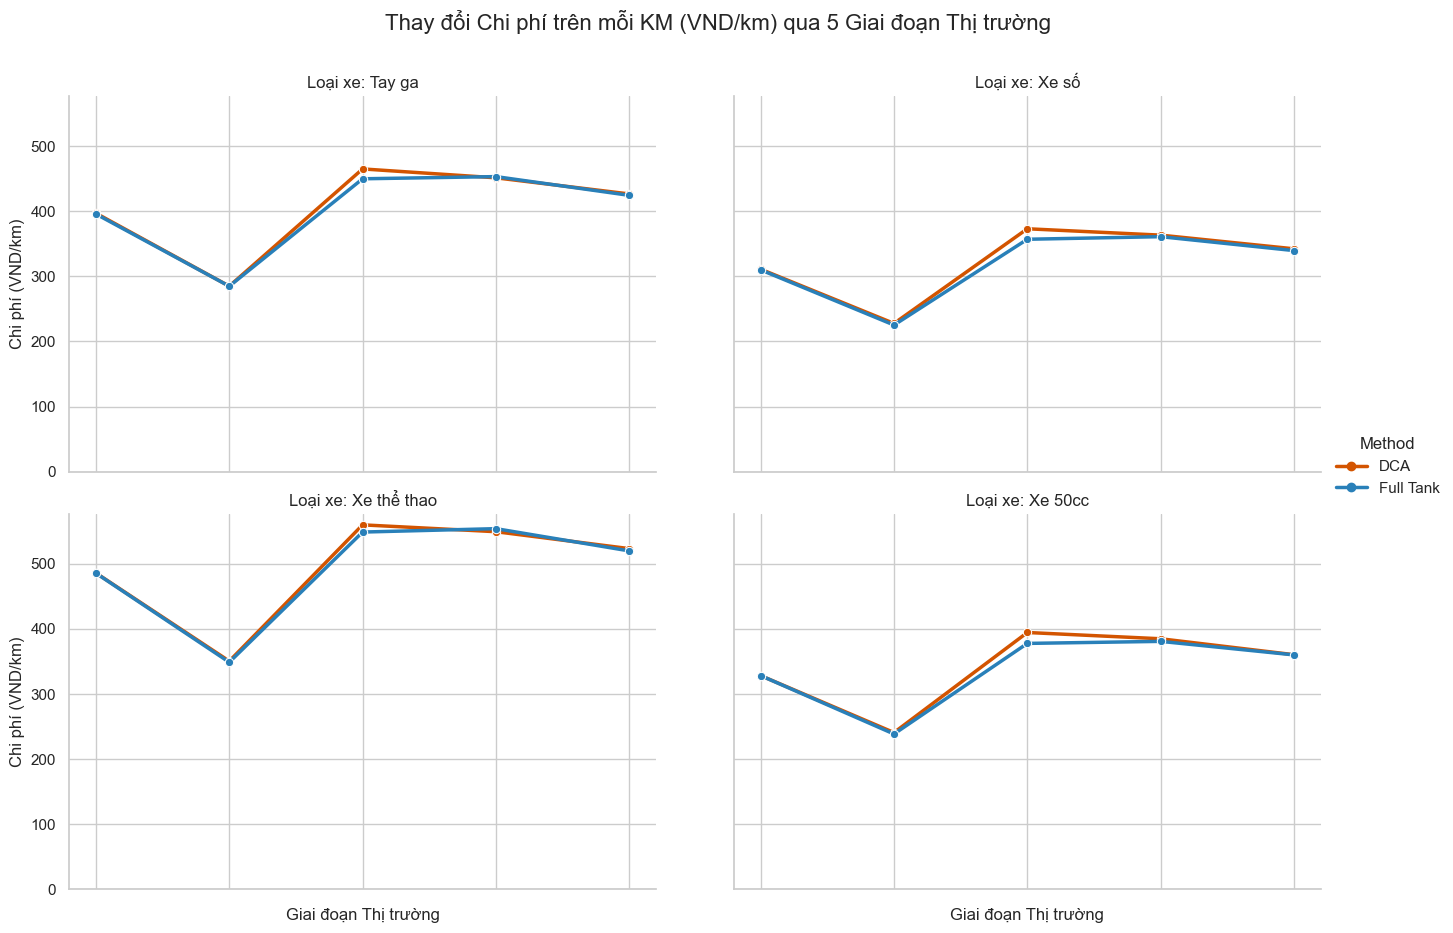

In [2]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

METHOD_COLORS = {
    'Full Tank': '#2980b9', # Blue
    'DCA': '#d35400'        # Orange
}

def analyze_by_market_phases(
    full_tank_path="/Users/my/DCA-on-filling-your-motorbike/01.fuel_purchase_history.json",
    dca_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json",
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not all(os.path.exists(p) for p in [full_tank_path, dca_path, csv_path]):
        print("Lỗi: Không tìm thấy một hoặc nhiều file dữ liệu.")
        return

    # 1. Process Bike Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip()
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    history_records = []
    
    # Map to hold consumption rates for calculating Cost per KM
    consumption_map = {}

    # 2. Parse FULL TANK Data
    with open(full_tank_path, 'r', encoding='utf-8') as f:
        ft_data = json.load(f)
        for bike_name, info in ft_data.items():
            bike_name = bike_name.strip()
            v_type = type_map.get(bike_name, "Khác")
            
            # Extract consumption rate
            cons_rate = info.get('specs', {}).get('consumption_rate', 2.0)
            consumption_map[bike_name] = cons_rate
            
            for record in info.get('history', []):
                price = record.get('price_per_liter', 0)
                history_records.append({
                    "bike_name": bike_name, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "type": v_type, "Method": "Full Tank",
                    "cost_per_km": price * (cons_rate / 100) # Price per KM calculation
                })

    # 3. Parse DCA Data
    with open(dca_path, 'r', encoding='utf-8') as f:
        dca_data = json.load(f)
        for bike_name, info in dca_data.items():
            bike_name = bike_name.strip()
            v_type = type_map.get(bike_name, "Khác")
            
            # Retrieve matching consumption rate
            cons_rate = consumption_map.get(bike_name, 2.0)
            
            for record in info.get('history', []):
                if record.get('type') == "Full-tank (Initial)":
                    continue
                price = record.get('price_per_liter', 0)
                history_records.append({
                    "bike_name": bike_name, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "type": v_type, "Method": "DCA",
                    "cost_per_km": price * (cons_rate / 100) # Price per KM calculation
                })

    # 4. Data Formatting & Time-Delta Calculation
    df = pd.DataFrame(history_records)
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
    
    # Calculate days between refuels
    df = df.sort_values(by=['Method', 'bike_name', 'date'])
    df['days_between'] = df.groupby(['Method', 'bike_name'])['date'].diff().dt.days

    # 5. Map Market Phases
    conditions = [
        (df['date'] >= '2018-08-01') & (df['date'] <= '2020-02-28'),
        (df['date'] >= '2020-03-01') & (df['date'] <= '2020-11-30'),
        (df['date'] >= '2020-12-01') & (df['date'] <= '2022-07-31'),
        (df['date'] >= '2022-08-01') & (df['date'] <= '2022-12-31'),
        (df['date'] >= '2023-01-01') & (df['date'] <= '2026-03-31')
    ]
    choices = [
        '1. Pre-COVID', 
        '2. COVID Crash', 
        '3. The Bull Run', 
        '4. The Correction', 
        '5. The New Normal'
    ]
    df['Market_Phase'] = np.select(conditions, choices, default='Unknown')
    df = df[df['Market_Phase'] != 'Unknown']

    sns.set_theme(style="whitegrid")

    # --- CHART 1: BILL SIZE BY MARKET PHASE ---
    plt.figure(figsize=(15, 7))
    sns.boxplot(
        data=df, 
        x='Market_Phase', 
        y='cost_vnd', 
        hue='Method', 
        palette=METHOD_COLORS,
        order=choices,
        fliersize=2
    )
    plt.title("Biến động Giá trị Hóa đơn qua các Giai đoạn Thị trường (Full Tank vs DCA)", fontsize=15, pad=15)
    plt.xlabel("Giai đoạn Thị trường", fontsize=12)
    plt.ylabel("Giá trị Bill (VND)", fontsize=12)
    plt.ylim(bottom=0) # Added to start Y-axis from 0
    plt.legend(title="Chiến lược")
    plt.tight_layout()
    plt.show()

    # --- CHART 2: TIME BETWEEN PURCHASES BY MARKET PHASE ---
    plt.figure(figsize=(15, 7))
    sns.boxplot(
        data=df.dropna(subset=['days_between']), 
        x='Market_Phase', 
        y='days_between', 
        hue='Method', 
        palette=METHOD_COLORS,
        order=choices,
        showfliers=False
    )
    plt.title("Khoảng cách thời gian đổ xăng (Ngày) qua các Giai đoạn", fontsize=15, pad=15)
    plt.xlabel("Giai đoạn Thị trường", fontsize=12)
    plt.ylabel("Số ngày giữa 2 lần đổ", fontsize=12)
    plt.ylim(bottom=0) # Added to start Y-axis from 0
    plt.legend(title="Chiến lược")
    plt.tight_layout()
    plt.show()

    # --- NEW CHART 3: AVERAGE COST PER KM ACROSS PHASES ---
    # We use sns.relplot with kind="line" to show the trend across phases for each bike type
    g = sns.relplot(
        data=df, 
        x='Market_Phase', 
        y='cost_per_km', 
        hue='Method', 
        col='type', 
        col_wrap=2,
        kind='line', 
        palette=METHOD_COLORS, 
        height=4.5, 
        aspect=1.5,
        marker='o', 
        linewidth=2.5, 
        errorbar=None
    )
    g.fig.suptitle("Thay đổi Chi phí trên mỗi KM (VND/km) qua 5 Giai đoạn Thị trường", y=1.05, fontsize=16)
    g.set_axis_labels("Giai đoạn Thị trường", "Chi phí (VND/km)")
    g.set_titles("Loại xe: {col_name}")
    g.set_xticklabels(rotation=15)
    g.set(ylim=(0, None)) # Added to start Y-axis from 0 for all facets
    plt.show()

if __name__ == "__main__":
    analyze_by_market_phases()

In [8]:
import pandas as pd
import json
import os

def calculate_savings_metrics(
    full_tank_path="/Users/my/DCA-on-filling-your-motorbike/01.fuel_purchase_history.json",
    dca_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json",
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not all(os.path.exists(p) for p in [full_tank_path, dca_path, csv_path]):
        print("Lỗi: Không tìm thấy một hoặc nhiều file dữ liệu.")
        return

    # 1. Process Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip()
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    records = []

    # 2. Parse FULL TANK Data
    with open(full_tank_path, 'r', encoding='utf-8') as f:
        ft_data = json.load(f)
        for bike_name, info in ft_data.items():
            v_type = type_map.get(bike_name.strip(), "Khác")
            for record in info.get('history', []):
                records.append({
                    "type": v_type, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "Method": "Full Tank", "purchases": 1
                })

    # 3. Parse DCA Data
    with open(dca_path, 'r', encoding='utf-8') as f:
        dca_data = json.load(f)
        for bike_name, info in dca_data.items():
            v_type = type_map.get(bike_name.strip(), "Khác")
            for record in info.get('history', []):
                if record.get('type') == "Full-tank (Initial)":
                    continue # Loại bỏ lần đổ đầy bình đầu tiên của DCA để so sánh công bằng
                records.append({
                    "type": v_type, "date": record['date'], 
                    "cost_vnd": record['cost_vnd'], "Method": "DCA", "purchases": 1
                })

    # 4. Dataframe Formatting
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
    df['month_year'] = df['date'].dt.to_period('M')
    df['year'] = df['date'].dt.year

    # Custom IQR Function
    def calc_iqr(x):
        return x.quantile(0.75) - x.quantile(0.25)

    # 5. Core Calculation Function
    def generate_report(period_col, period_name):
        print(f"\n{'='*65}\nBÁO CÁO TIẾT KIỆM - CẤP ĐỘ: {period_name.upper()}\n{'='*65}")
        
        # --- LOGIC FOR MONTHLY AND YEARLY (STATISTICS) ---
        if period_col is not None:
            groupby_cols = ['type', period_col, 'Method']
            grouped = df.groupby(groupby_cols)[['cost_vnd', 'purchases']].sum().unstack('Method').fillna(0)
            grouped.columns = [f"{col[0]}_{col[1]}" for col in grouped.columns]
            
            dca_cost = grouped.get('cost_vnd_DCA', 0)
            ft_cost = grouped.get('cost_vnd_Full Tank', 0)
            dca_purchases = grouped.get('purchases_DCA', 0)
            ft_purchases = grouped.get('purchases_Full Tank', 0)
            
            money_saved = dca_cost - ft_cost
            pct_money_saved = (money_saved / dca_cost.replace(0, 1)) * 100 
            
            trips_saved = dca_purchases - ft_purchases
            pct_trips_saved = (trips_saved / dca_purchases.replace(0, 1)) * 100
            
            is_cheaper = ft_cost < dca_cost

            df_calc = pd.DataFrame({
                'is_cheaper': is_cheaper,
                'pct_money_saved': pct_money_saved,
                'pct_trips_saved': pct_trips_saved
            }).reset_index()

            summary = df_calc.groupby('type').agg(
                total_periods=(period_col, 'count'),
                won_periods=('is_cheaper', 'sum'),
                avg_pct_money_saved=('pct_money_saved', 'mean'),
                sd_pct_money_saved=('pct_money_saved', 'std'),
                iqr_pct_money_saved=('pct_money_saved', calc_iqr),
                avg_pct_trips_saved=('pct_trips_saved', 'mean'),
                sd_pct_trips_saved=('pct_trips_saved', 'std'),
                iqr_pct_trips_saved=('pct_trips_saved', calc_iqr)
            ).fillna(0)

            for bike_type, row in summary.iterrows():
                win_rate_str = f"{int(row['won_periods'])} / {int(row['total_periods'])} {period_name.lower()}"
                print(f"--- Loại xe: {bike_type.upper()} ---")
                print(f"  + Số lần Full Tank tiết kiệm tiền hơn: {win_rate_str}")
                print(f"  + % Tiền tiết kiệm:")
                print(f"      - Trung bình (Mean):       {row['avg_pct_money_saved']:>7.2f}%")
                print(f"      - Độ lệch chuẩn (SD):      {row['sd_pct_money_saved']:>7.2f}%")
                print(f"      - Khoảng tứ phân vị (IQR): {row['iqr_pct_money_saved']:>7.2f}%")
                print(f"  + % Số lần ghé trạm xăng giảm được:")
                print(f"      - Trung bình (Mean):       {row['avg_pct_trips_saved']:>7.2f}%")
                print(f"      - Độ lệch chuẩn (SD):      {row['sd_pct_trips_saved']:>7.2f}%")
                print(f"      - Khoảng tứ phân vị (IQR): {row['iqr_pct_trips_saved']:>7.2f}%\n")
                
        # --- LOGIC FOR ALL-TIME (ABSOLUTE MONEY + PERCENTAGE FOR TRIPS) ---
        else:
            groupby_cols = ['type', 'Method']
            grouped = df.groupby(groupby_cols)[['cost_vnd', 'purchases']].sum().unstack('Method').fillna(0)
            grouped.columns = [f"{col[0]}_{col[1]}" for col in grouped.columns]
            
            df_calc = grouped.reset_index()
            
            for _, row in df_calc.iterrows():
                bike_type = row['type']
                dca_cost = row.get('cost_vnd_DCA', 0)
                ft_cost = row.get('cost_vnd_Full Tank', 0)
                dca_purchases = row.get('purchases_DCA', 0)
                ft_purchases = row.get('purchases_Full Tank', 0)
                
                money_saved = dca_cost - ft_cost
                trips_saved = dca_purchases - ft_purchases
                
                # Calculate percentage for trips safely
                pct_trips_saved = (trips_saved / max(dca_purchases, 1)) * 100
                
                if money_saved > 0:
                    money_winner = "Full Tank"
                    money_val = money_saved
                elif money_saved < 0:
                    money_winner = "DCA"
                    money_val = abs(money_saved)
                else:
                    money_winner = "Hòa"
                    money_val = 0
                
                print(f"--- Loại xe: {bike_type.upper()} ---")
                print(f"  + Tổng tiền tiết kiệm ròng:           {money_val:,.0f} VND (Chiến lược rẻ hơn: {money_winner})")
                print(f"      - Tổng chi phí DCA:               {dca_cost:,.0f} VND")
                print(f"      - Tổng chi phí Full Tank:         {ft_cost:,.0f} VND")
                print(f"  + % Số lần ghé trạm xăng giảm được:   {pct_trips_saved:.2f}% (Tương đương {int(trips_saved)} lần)")
                print(f"      - Tổng số lần đổ DCA:             {int(dca_purchases)} lần")
                print(f"      - Tổng số lần đổ Full Tank:       {int(ft_purchases)} lần\n")

    # 6. Execute Reports
    generate_report('month_year', 'Tháng')
    generate_report('year', 'Năm')
    generate_report(None, 'Từ đầu kỳ quan sát')

if __name__ == "__main__":
    calculate_savings_metrics()


BÁO CÁO TIẾT KIỆM - CẤP ĐỘ: THÁNG
--- Loại xe: TAY GA ---
  + Số lần Full Tank tiết kiệm tiền hơn: 38 / 91 tháng
  + % Tiền tiết kiệm:
      - Trung bình (Mean):       -1165552.31%
      - Độ lệch chuẩn (SD):      11118643.42%
      - Khoảng tứ phân vị (IQR):   11.62%
  + % Số lần ghé trạm xăng giảm được:
      - Trung bình (Mean):          8.77%
      - Độ lệch chuẩn (SD):       108.72%
      - Khoảng tứ phân vị (IQR):   29.33%

--- Loại xe: XE 50CC ---
  + Số lần Full Tank tiết kiệm tiền hơn: 44 / 91 tháng
  + % Tiền tiết kiệm:
      - Trung bình (Mean):       -456849.77%
      - Độ lệch chuẩn (SD):      4358055.37%
      - Khoảng tứ phân vị (IQR):   20.85%
  + % Số lần ghé trạm xăng giảm được:
      - Trung bình (Mean):         16.39%
      - Độ lệch chuẩn (SD):        48.96%
      - Khoảng tứ phân vị (IQR):   35.71%

--- Loại xe: XE SỐ ---
  + Số lần Full Tank tiết kiệm tiền hơn: 42 / 91 tháng
  + % Tiền tiết kiệm:
      - Trung bình (Mean):       -509106.95%
      - Độ lệch chuẩn

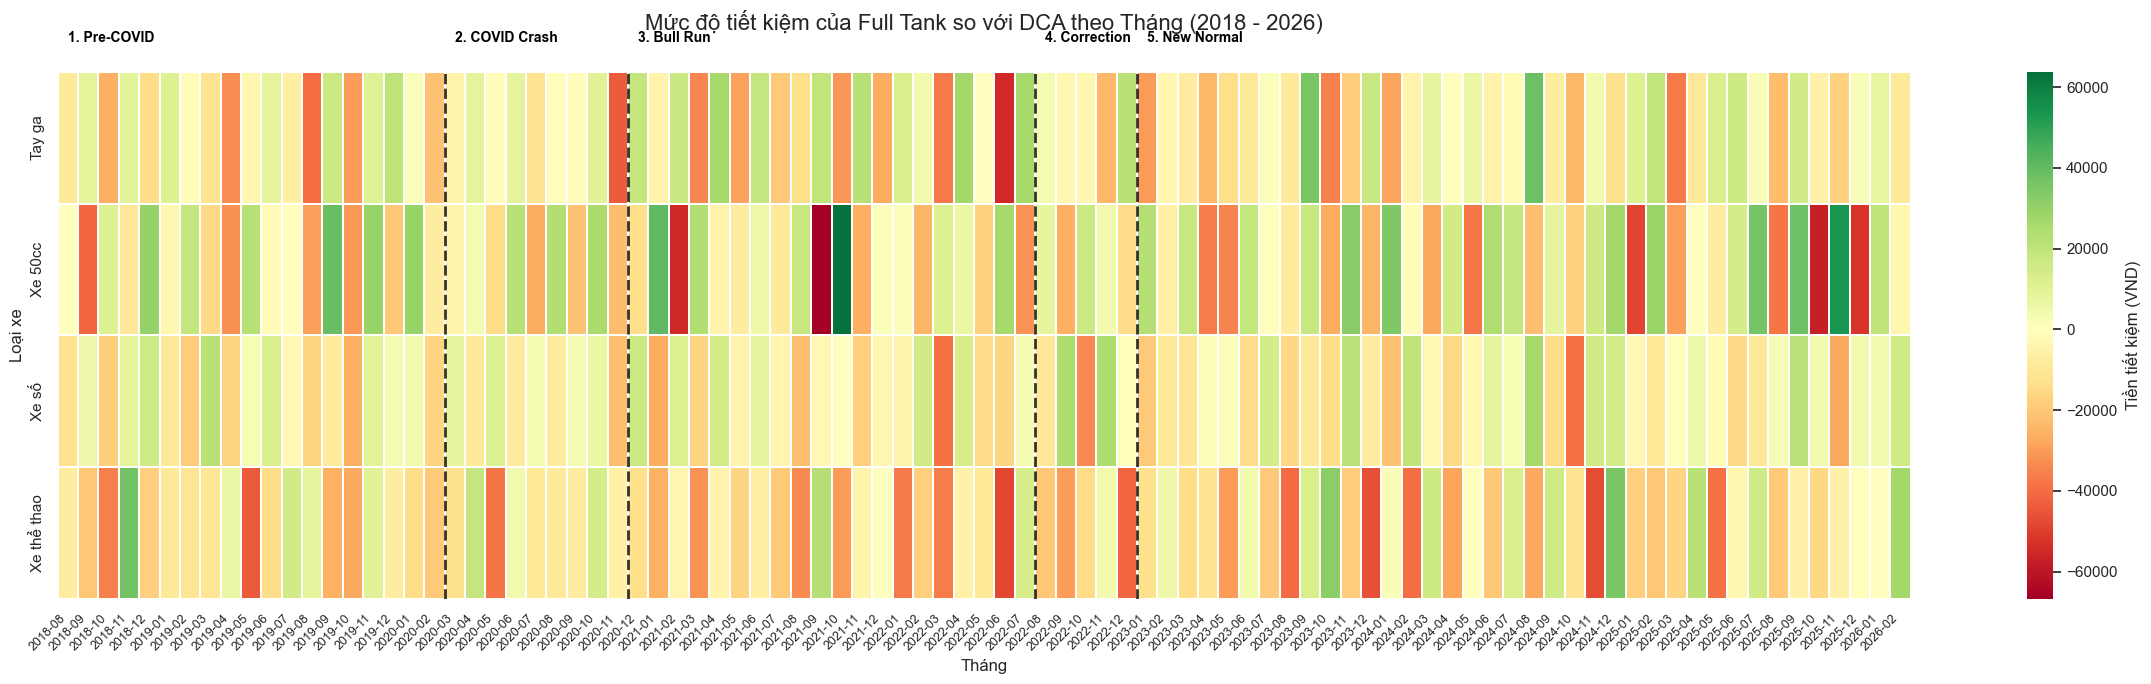

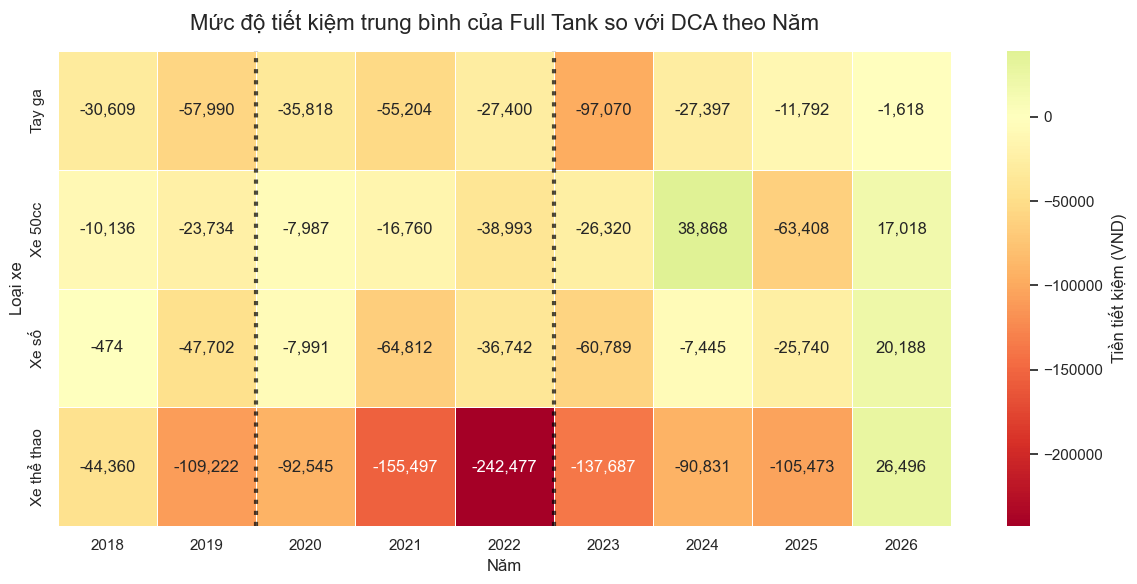

In [3]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

def plot_savings_heatmaps(
    full_tank_path="/Users/my/DCA-on-filling-your-motorbike/01.fuel_purchase_history.json",
    dca_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json",
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not all(os.path.exists(p) for p in [full_tank_path, dca_path, csv_path]):
        print("Lỗi: Không tìm thấy một hoặc nhiều file dữ liệu.")
        return

    # 1. Process Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip()
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    records = []

    # 2. Parse FULL TANK Data
    with open(full_tank_path, 'r', encoding='utf-8') as f:
        ft_data = json.load(f)
        for bike_name, info in ft_data.items():
            for record in info.get('history', []):
                records.append({
                    "bike_name": bike_name.strip(),
                    "date": record['date'],
                    "cost_vnd": record['cost_vnd'],
                    "Method": "Full Tank"
                })

    # 3. Parse DCA Data
    with open(dca_path, 'r', encoding='utf-8') as f:
        dca_data = json.load(f)
        for bike_name, info in dca_data.items():
            for record in info.get('history', []):
                records.append({
                    "bike_name": bike_name.strip(),
                    "date": record['date'],
                    "cost_vnd": record['cost_vnd'],
                    "Method": "DCA"
                })

    # 4. Dataframe Formatting
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
    df['month_year'] = df['date'].dt.to_period('M').astype(str)
    df['year'] = df['date'].dt.year.astype(str)
    
    # Map loại xe sau khi đã tạo dataframe
    df['type'] = df['bike_name'].map(type_map).fillna("Khác")

    sns.set_theme(style="white")

    # --- HEATMAP 1: MONTHLY SAVINGS ---
    monthly_grouped = df.groupby(['type', 'bike_name', 'month_year', 'Method'])['cost_vnd'].sum().unstack('Method').fillna(0)
    monthly_grouped['Savings'] = monthly_grouped['DCA'] - monthly_grouped['Full Tank']
    monthly_type_savings = monthly_grouped.reset_index().groupby(['type', 'month_year'])['Savings'].mean().reset_index()
    monthly_pivot = monthly_type_savings.pivot(index='type', columns='month_year', values='Savings').fillna(0)

    plt.figure(figsize=(24, 7))
    ax1 = sns.heatmap(monthly_pivot, cmap="RdYlGn", center=0, annot=False, linewidths=.2, cbar_kws={'label': 'Tiền tiết kiệm (VND)'})
    
    # Add vertical lines for Market Phases (Monthly)
    monthly_phases = {
        '2. COVID Crash': '2020-03',
        '3. Bull Run': '2020-12',
        '4. Correction': '2022-08',
        '5. New Normal': '2023-01'
    }
    
    col_names = list(monthly_pivot.columns)
    for phase_name, start_month in monthly_phases.items():
        if start_month in col_names:
            idx = col_names.index(start_month)
            ax1.axvline(x=idx, color='black', linestyle='--', lw=2, alpha=0.8)
            # Add text label slightly to the right of the line
            ax1.text(idx + 0.5, -0.2, phase_name, color='black', rotation=0, 
                     ha='left', va='bottom', fontweight='bold', fontsize=10)
            
    # Add label for the first phase
    ax1.text(0.5, -0.2, '1. Pre-COVID', color='black', rotation=0, 
             ha='left', va='bottom', fontweight='bold', fontsize=10)

    plt.title("Mức độ tiết kiệm của Full Tank so với DCA theo Tháng (2018 - 2026)", fontsize=16, pad=30)
    plt.xlabel("Tháng")
    plt.ylabel("Loại xe")
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- HEATMAP 2: YEARLY SAVINGS ---
    yearly_grouped = df.groupby(['type', 'bike_name', 'year', 'Method'])['cost_vnd'].sum().unstack('Method').fillna(0)
    yearly_grouped['Savings'] = yearly_grouped['DCA'] - yearly_grouped['Full Tank']
    yearly_type_savings = yearly_grouped.reset_index().groupby(['type', 'year'])['Savings'].mean().reset_index()
    yearly_pivot = yearly_type_savings.pivot(index='type', columns='year', values='Savings').fillna(0)

    plt.figure(figsize=(12, 6))
    ax2 = sns.heatmap(yearly_pivot, cmap="RdYlGn", center=0, annot=True, fmt=",.0f", linewidths=.5, cbar_kws={'label': 'Tiền tiết kiệm (VND)'})
    
    # Add vertical lines for Market Phases (Yearly - Approximate since phases cross years)
    yearly_cutoffs = {
        'Crash/Bull Run': '2020', # Major shifts happened within 2020
        'New Normal Starts': '2023'
    }
    
    year_cols = list(yearly_pivot.columns)
    for label, y_str in yearly_cutoffs.items():
        if y_str in year_cols:
            idx = year_cols.index(y_str)
            ax2.axvline(x=idx, color='black', linestyle=':', lw=3, alpha=0.7)

    plt.title("Mức độ tiết kiệm trung bình của Full Tank so với DCA theo Năm", fontsize=16, pad=15)
    plt.xlabel("Năm")
    plt.ylabel("Loại xe")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_savings_heatmaps()